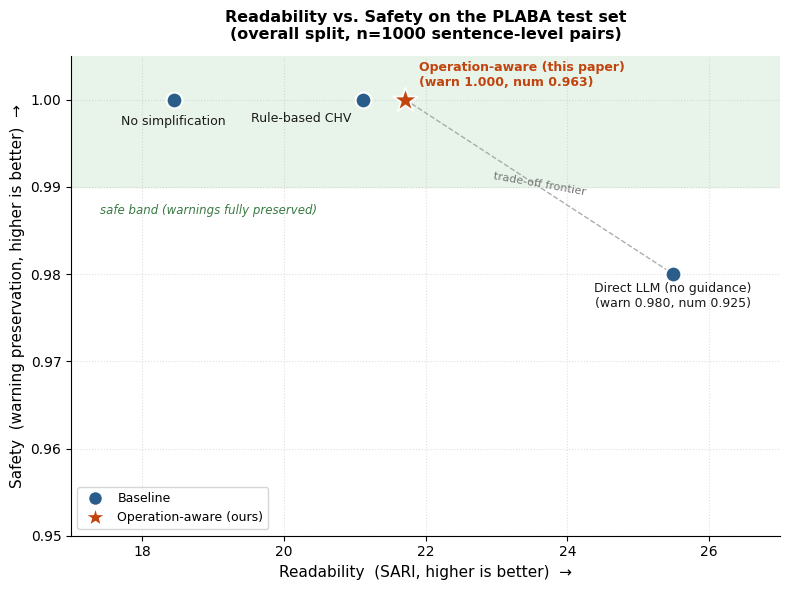

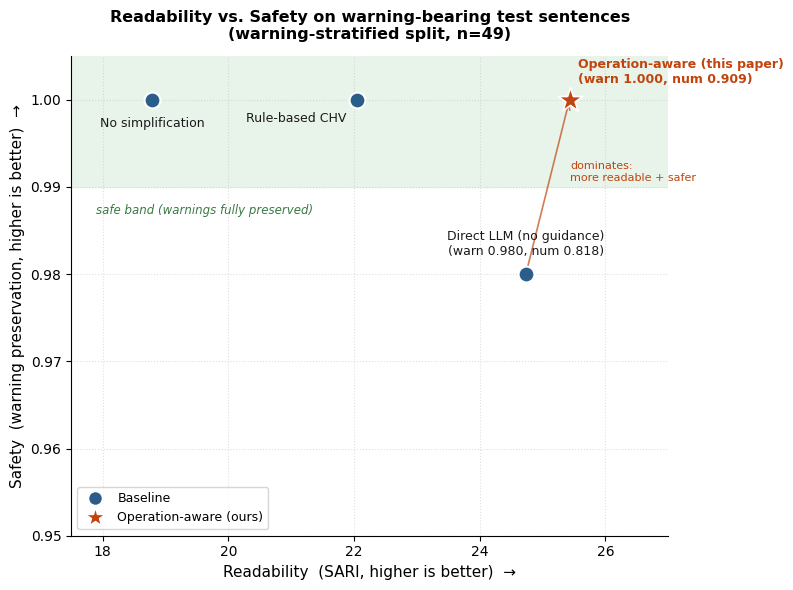

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import os

CSV = "results/final_evaluation_testset.csv"
OUT = "results"
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(CSV)

LABELS = {
    "baseline1_no_simplification": "No simplification",
    "baseline2_rule_based_chv":    "Rule-based CHV",
    "baseline3_direct_llm":        "Direct LLM (no guidance)",
    "baseline4_operation_aware":   "Operation-aware (this paper)",
}
OURS = "baseline4_operation_aware"


def rows(split):
    d = df[df["split"] == split].set_index("baseline")
    return {b: (float(d.loc[b, "SARI"]),
                float(d.loc[b, "warning_preservation"]),
                float(d.loc[b, "numerical_preservation"]))
            for b in LABELS}


def plot(split, title, fname, xlim, ylim, offsets, dominates=False):
    data = rows(split)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axhspan(0.99, ylim[1], color="#e8f4ea", zorder=0)
    ax.text(xlim[0] + 0.4, 0.988, "safe band (warnings fully preserved)",
            fontsize=8.5, color="#3a7a45", ha="left", va="top", style="italic")

    ours = data[OURS]
    llm = data["baseline3_direct_llm"]

    # trade-off frontier (overall) or dominance arrow (stratified)
    if dominates:
        ax.annotate("", xy=(ours[0], ours[1]), xytext=(llm[0], llm[1]),
                    arrowprops=dict(arrowstyle="->", color="#c1440e", lw=1.2, alpha=0.7))
        ax.text(llm[0] + 0.7, 0.9905, "dominates:\nmore readable + safer",
                fontsize=8, color="#c1440e", ha="left", va="bottom")
    else:
        ax.plot([ours[0], llm[0]], [ours[1], llm[1]], "--",
                color="#999999", linewidth=1, zorder=2, alpha=0.8)
        ax.text((ours[0] + llm[0]) / 2, (ours[1] + llm[1]) / 2 - 0.001,
                "trade-off frontier", fontsize=8, color="#777777",
                ha="center", rotation=-10)

    for b, label in LABELS.items():
        sari, warn, num = data[b]
        dx, dy, ha = offsets[b]
        if b == OURS:
            ax.scatter(sari, warn, s=340, marker="*", color="#c1440e",
                       edgecolor="white", linewidth=1.2, zorder=6)
            ax.annotate(f"{label}\n(warn {warn:.3f}, num {num:.3f})", (sari, warn),
                        textcoords="offset points", xytext=(dx, dy), ha=ha,
                        fontsize=9, color="#c1440e", fontweight="bold")
        else:
            ax.scatter(sari, warn, s=130, color="#2b5d8a",
                       edgecolor="white", linewidth=1.5, zorder=5)
            note = label if warn == 1.0 else f"{label}\n(warn {warn:.3f}, num {num:.3f})"
            ax.annotate(note, (sari, warn), textcoords="offset points",
                        xytext=(dx, dy), ha=ha, fontsize=9, color="#1a1a1a")

    ax.set_xlabel("Readability  (SARI, higher is better)  \u2192", fontsize=11)
    ax.set_ylabel("Safety  (warning preservation, higher is better)  \u2192", fontsize=11)
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=12)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#2b5d8a",
               markersize=10, label="Baseline"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#c1440e",
               markersize=15, label="Operation-aware (ours)"),
    ], loc="lower left", fontsize=9, frameon=True)

    fig.tight_layout()
    fig.savefig(f"{OUT}/{fname}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT}/{fname}.pdf", bbox_inches="tight")
    plt.show()


# overall split (all 1000 test sentences): safety-readability trade-off
plot("overall",
     "Readability vs. Safety on the PLABA test set\n(overall split, n=1000 sentence-level pairs)",
     "readability_safety_scatter",
     xlim=(17, 27), ylim=(0.95, 1.005),
     offsets={
         "baseline1_no_simplification": (0, -18, "center"),
         "baseline2_rule_based_chv":    (-8, -16, "right"),
         "baseline3_direct_llm":        (0, -24, "center"),
         "baseline4_operation_aware":   (10, 10, "left"),
     })

# warning-stratified split (49 warning-bearing sentences): clean dominance
plot("warning_stratified",
     "Readability vs. Safety on warning-bearing test sentences\n(warning-stratified split, n=49)",
     "readability_safety_scatter_stratified",
     xlim=(17.5, 27), ylim=(0.95, 1.005),
     offsets={
         "baseline1_no_simplification": (0, -20, "center"),
         "baseline2_rule_based_chv":    (-8, -16, "right"),
         "baseline3_direct_llm":        (0, 14, "center"),
         "baseline4_operation_aware":   (6, 12, "left"),
     },
     dominates=True)